In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import os
import random
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms

from src.utils.config import load_config
from src.models.model import ReconstructionModel

In [2]:
config = load_config("../configs/config.yaml")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ReconstructionModel(config).to(device)
model.load_state_dict(torch.load("../outputs/model_best.pth", map_location=device))
model.eval()

c:\Shivansh\aiml\shapenet\venv_shapenet\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Shivansh\aiml\shapenet\venv_shapenet\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ReconstructionModel(
  (encoder): Encoder(
    (feature_extractor): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): Bat

In [3]:
transform = transforms.Compose([
    transforms.Resize((config["data"]["image_size"], config["data"]["image_size"])),
    transforms.ToTensor(),
])

In [7]:
def show_voxel(voxel, threshold=0.5):
    voxel = voxel.squeeze()  # [32,32,32]

    voxel = np.rot90(voxel, k=1, axes=(1, 2))  # (y, z)
    # voxel = np.rot90(voxel, k=1, axes=(0, 2))  # (x, z)

    voxel = (voxel > threshold)

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.voxels(voxel, edgecolor='k')

    plt.show()

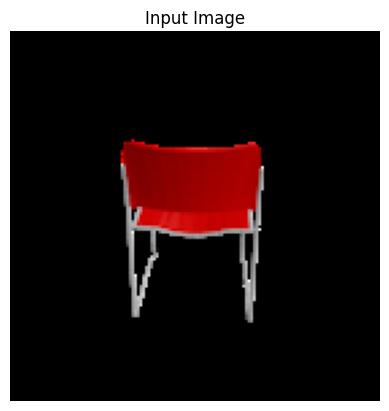

🔵 Predicted Voxel


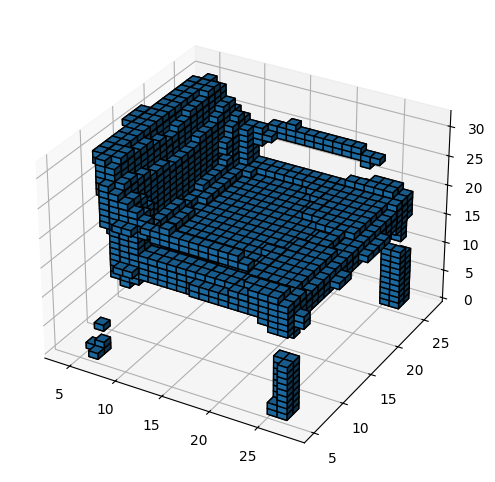

🟢 Ground Truth Voxel


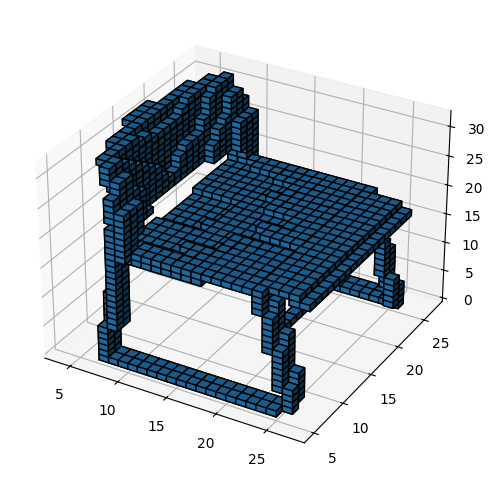

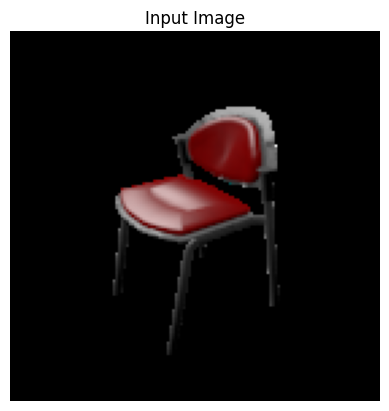

🔵 Predicted Voxel


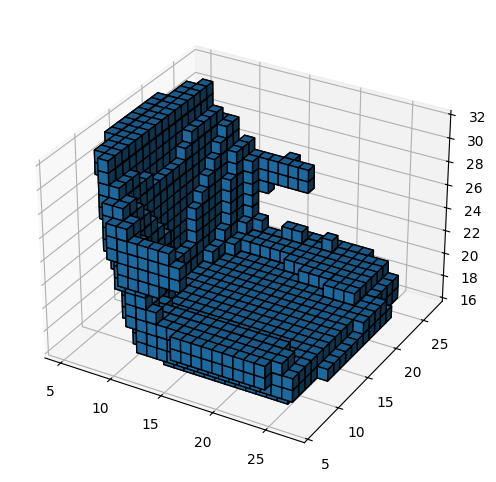

🟢 Ground Truth Voxel


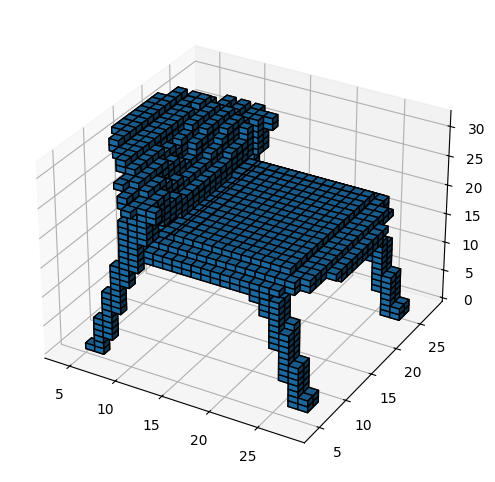

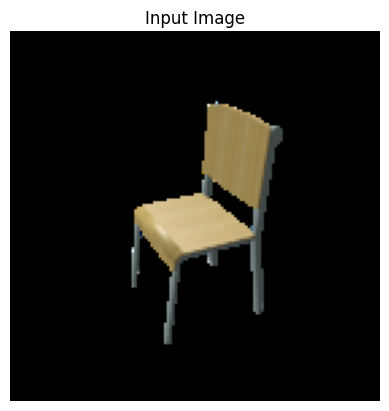

🔵 Predicted Voxel


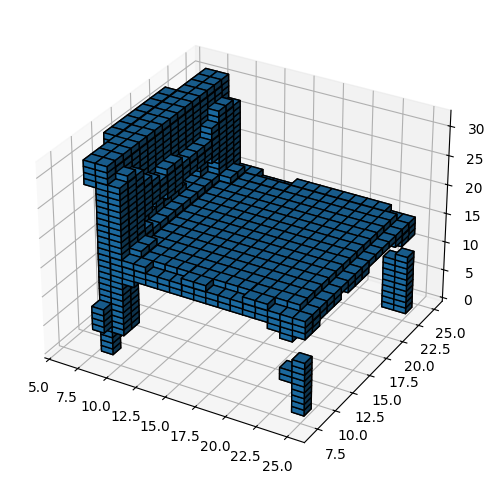

🟢 Ground Truth Voxel


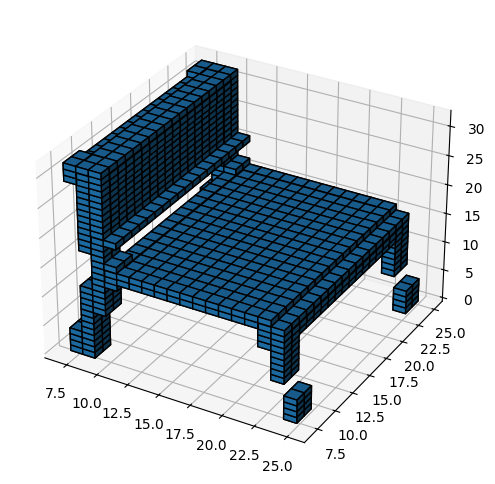

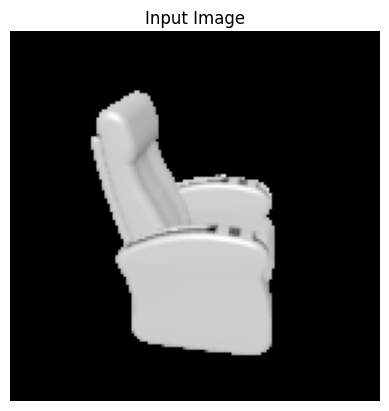

🔵 Predicted Voxel


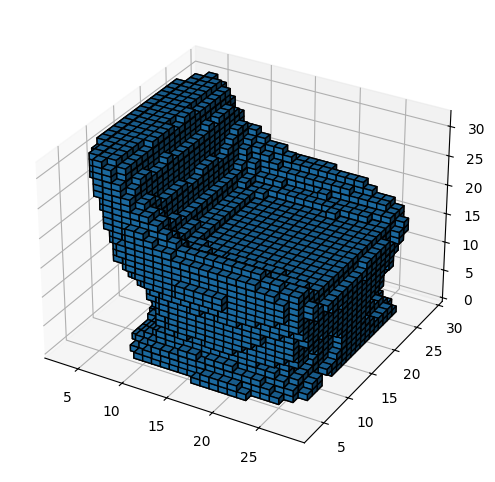

🟢 Ground Truth Voxel


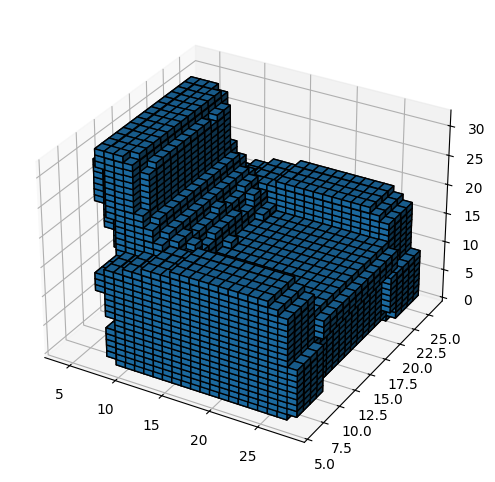

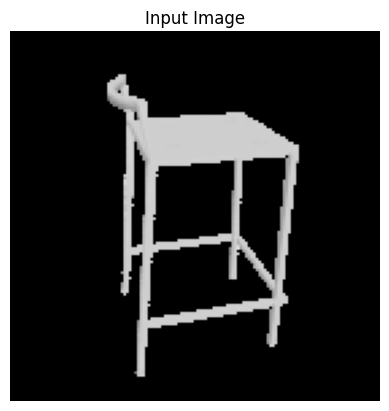

🔵 Predicted Voxel


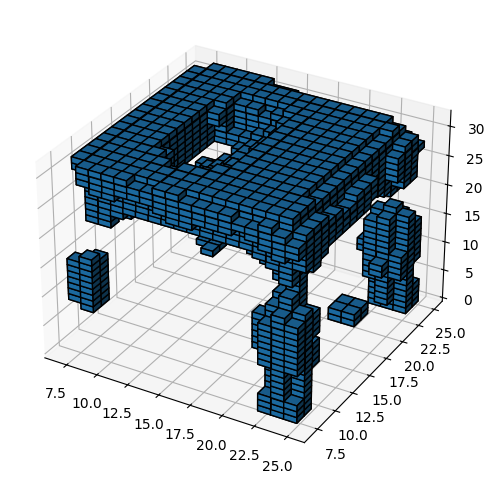

🟢 Ground Truth Voxel


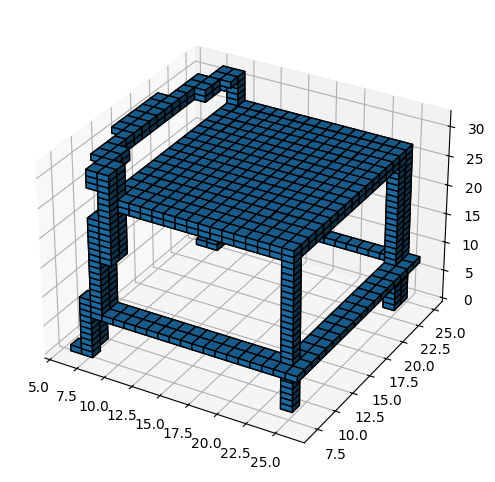

In [8]:
rendering_path = config["paths"]["rendering_dir"]
voxel_path = config["paths"]["voxel_dir"]
class_id = config["data"]["class_id"]

render_class_path = os.path.join(rendering_path, class_id)
voxel_class_path = os.path.join(voxel_path, class_id)

model_ids = os.listdir(render_class_path)

random_models = random.sample(model_ids, 5)

for model_id in random_models:
    render_dir = os.path.join(render_class_path, model_id, "rendering")
    voxel_file = os.path.join(voxel_class_path, model_id, "model.binvox")

    if not os.path.exists(render_dir) or not os.path.exists(voxel_file):
        continue

    images = [img for img in os.listdir(render_dir) if img.endswith(".png")]
    if len(images) == 0:
        continue

    img_name = random.choice(images)
    image_path = os.path.join(render_dir, img_name)

    # 🔥 Load image
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    # 🔥 Model prediction
    with torch.no_grad():
        pred_voxel = model(image_tensor).cpu().numpy()

    # 🔥 Load ground truth voxel
    import numpy as np
    from src.utils import binvox_rw

    with open(voxel_file, 'rb') as f:
        gt_voxel = binvox_rw.read_as_3d_array(f).data.astype(np.float32)

    gt_voxel = np.expand_dims(gt_voxel, axis=0)  # match shape [1,32,32,32]

    # 🔥 Show input image
    plt.imshow(image)
    plt.title("Input Image")
    plt.axis("off")
    plt.show()

    # 🔥 Show predicted voxel
    print("🔵 Predicted Voxel")
    show_voxel(pred_voxel)

    # 🔥 Show ground truth voxel
    print("🟢 Ground Truth Voxel")
    show_voxel(gt_voxel)